<a href="https://colab.research.google.com/github/sukdevmahapatra/variable-star-classification/blob/main/Notebook/Variable_Star_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 1, Assignment : Introduction to Python and Colab

**Name:** Sukdev Mahapatra  
**Country:** India  

In [ ]:
print("Hello, BRICS Astronomy")

Hello, BRICS Astronomy


# Week 9, Assignment : Analysis of a Variable Star using TESS Light Curve Data


SearchResult containing 6 data products.

 #     mission     year   author  exptime target_name distance
                                     s                 arcsec 
--- -------------- ---- --------- ------- ----------- --------
  0 TESS Sector 14 2019      SPOC     120   159717514      0.0
  1 TESS Sector 40 2021      SPOC     120   159717514      0.0
  2 TESS Sector 41 2021      SPOC     120   159717514      0.0
  3 TESS Sector 14 2019 TESS-SPOC    1800   159717514      0.0
  4 TESS Sector 40 2021 TESS-SPOC     600   159717514      0.0
  5 TESS Sector 41 2021 TESS-SPOC     600   159717514      0.0


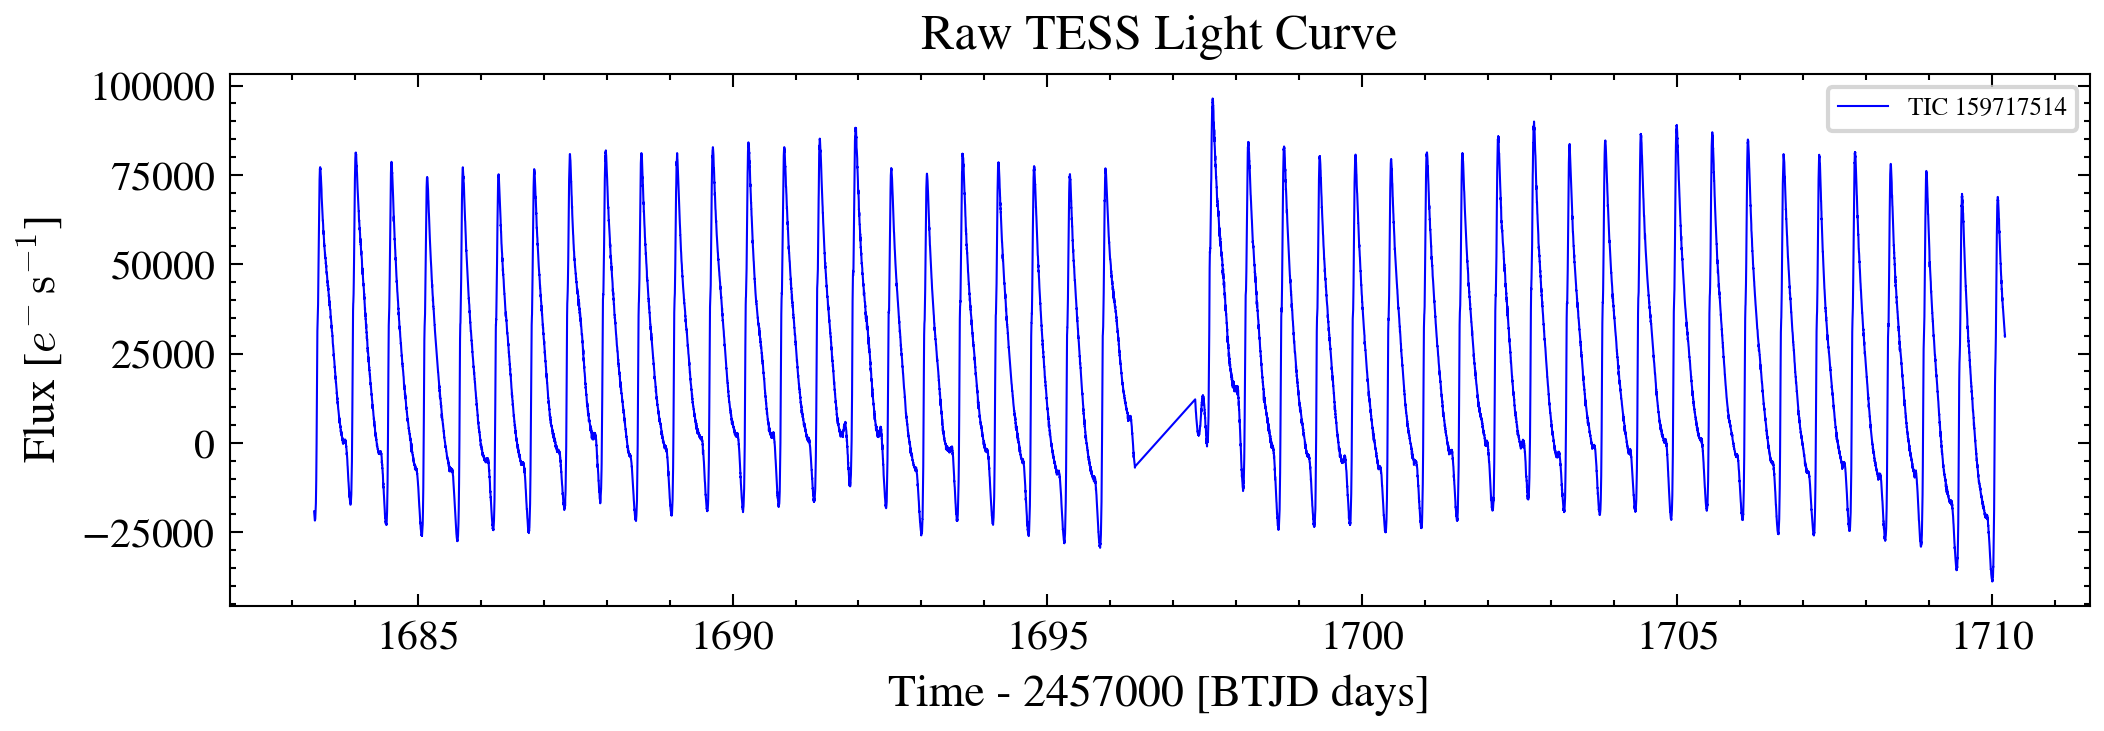

In [7]:
import lightkurve as lk
import numpy as np
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(['science', 'nature', 'no-latex'])

search_result = lk.search_lightcurve(
    "RR Lyrae",
    mission="TESS"
)

print(search_result)

lc = search_result[0].download()

fig, ax = plt.subplots(figsize=(8,2.3), dpi=300)

ax.plot(lc.time.value, lc.flux.value,
        color='blue',
        lw=0.5,
        label=f"TIC {lc.meta.get('TARGETID', '')}")

ax.set_title("Raw TESS Light Curve", fontsize=12)
ax.set_xlabel("Time - 2457000 [BTJD days]", fontsize=11)
ax.set_ylabel(r"Flux [$e^{-}\,\mathrm{s}^{-1}$]", fontsize=11)
ax.legend(frameon=True, fontsize=6)
ax.tick_params(
    axis='both',
    which='major',
    labelsize=10,
    direction='in',
    top=True,
    right=True
)
plt.show()

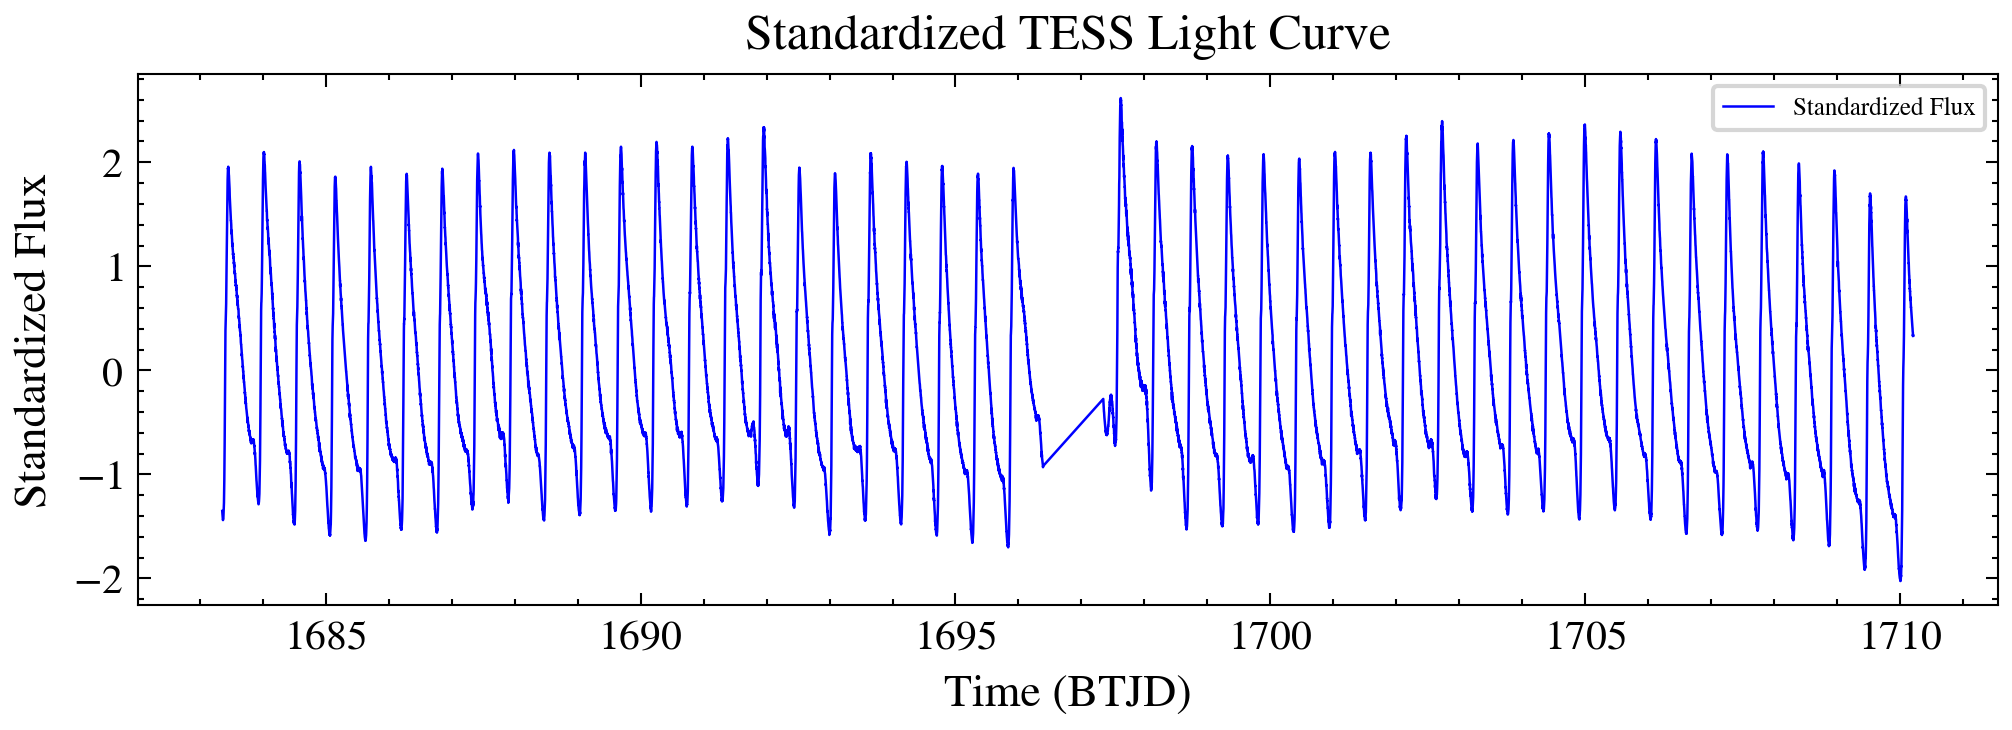

In [3]:
lc_clean = lc.remove_nans()

flux = lc_clean.flux.value
flux_std = (flux - np.mean(flux)) / np.std(flux)

fig, ax = plt.subplots(figsize=(8, 2.3), dpi=300)

ax.plot(
    lc_clean.time.value,
    flux_std,
    color='blue',
    lw=0.6,
    label='Standardized Flux'
)

ax.set_title("Standardized TESS Light Curve", fontsize=12)
ax.set_xlabel("Time (BTJD)", fontsize=11)
ax.set_ylabel("Standardized Flux", fontsize=11)

ax.legend(frameon=True, fontsize=6)

ax.tick_params(
    axis='both',
    which='major',
    labelsize=10,
    direction='in',
    top=True,
    right=True
)

ax.minorticks_on()
plt.show()

In [4]:
flux = lc_clean.flux.value

print("Mean =", np.mean(flux))
print("Standard Deviation =", np.std(flux))
print("Minimum =", np.min(flux))
print("Maximum =", np.max(flux))

Mean = 20172.203
Standard Deviation = 29116.314
Minimum = -38778.98
Maximum = 96373.305


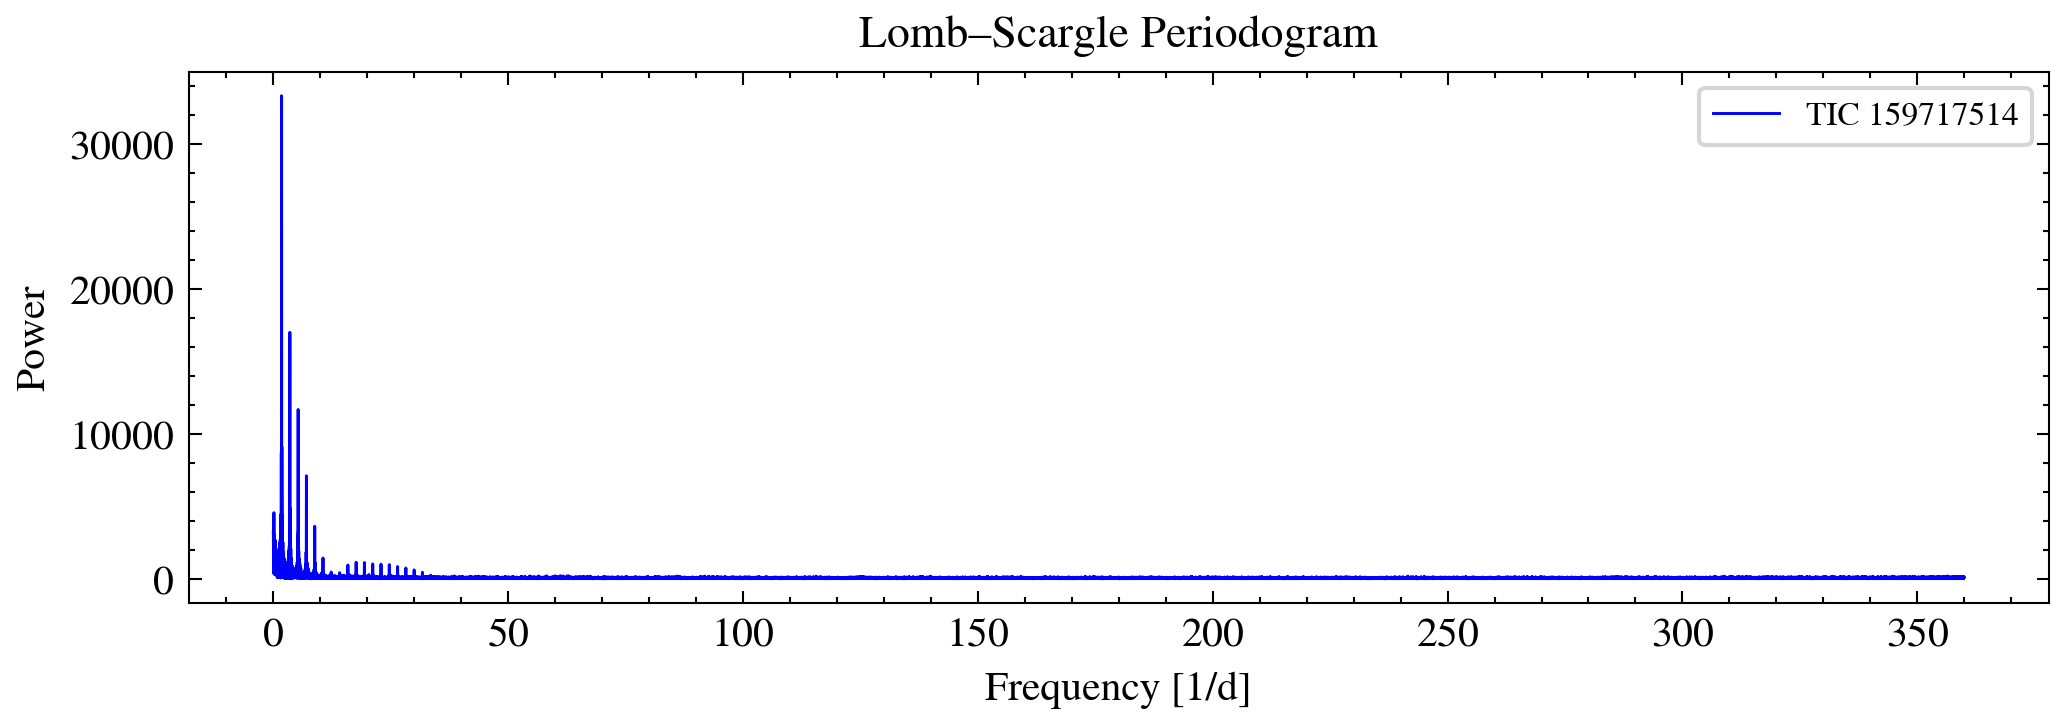

Best Period = 0.566455 d


In [5]:
periodogram = lc_clean.to_periodogram()

fig, ax = plt.subplots(figsize=(8,2.3), dpi=300)

periodogram.plot(ax=ax, color='blue', lw=0.7)

ax.set_title("Lomb–Scargle Periodogram", fontsize=11)
ax.set_xlabel("Frequency [1/d]", fontsize=10)
ax.set_ylabel("Power", fontsize=10)

ax.tick_params(direction='in', which='both', top=True, right=True, labelsize=10)
ax.legend(frameon=True, fontsize=8)
ax.minorticks_on()
plt.show()

best_period = periodogram.period_at_max_power
print(f"Best Period = {best_period:.6f}")

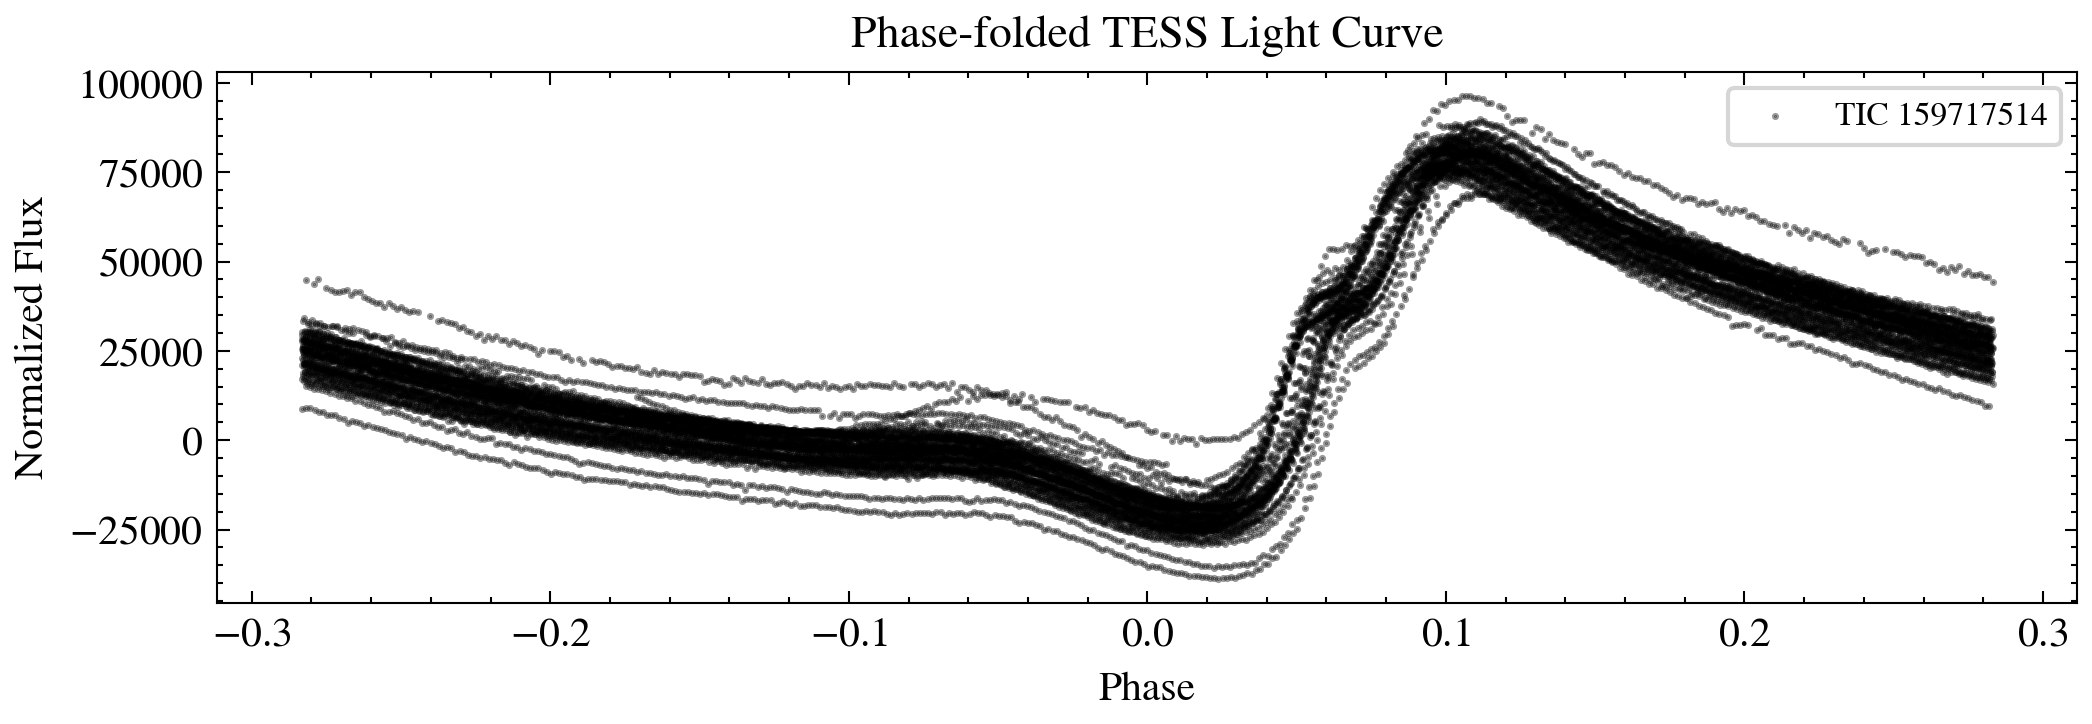

In [6]:
folded = lc_clean.fold(period=best_period)

fig, ax = plt.subplots(figsize=(8,2.3), dpi=300)

folded.scatter(
    ax=ax,
    color='black',
    s=2,          # marker size
    alpha=0.4
)

ax.set_title("Phase-folded TESS Light Curve", fontsize=11)
ax.set_xlabel("Phase", fontsize=10)
ax.set_ylabel("Normalized Flux", fontsize=10)

ax.tick_params(direction='in', top=True, right=True, labelsize=10)
ax.legend(frameon=True, fontsize=8)
ax.minorticks_on()

plt.show()

# Week 10, Assignment : Explainable Classification of Galaxies, QSOs, and Stars Using SDSS Data
---

## Objective

This project aims to classify astronomical objects into three categories—Galaxy, QSO (Quasar), and Star—using photometric and spectroscopic data from the Sloan Digital Sky Survey (SDSS). Machine learning models are trained to perform the classification, and Explainable Artificial Intelligence (XAI) techniques are used to understand how different astronomical features influence the model's predictions.

## Introduction

Modern sky surveys generate enormous volumes of astronomical data, making manual classification of celestial objects impractical. Machine learning provides efficient methods for automatically distinguishing between stars, galaxies, and quasars using photometric and spectroscopic measurements.

However, high prediction accuracy alone is insufficient in scientific applications. Astronomers also need to understand why a model makes a particular prediction. Explainable Artificial Intelligence (XAI) provides tools that reveal the contribution of each feature, increasing confidence in machine learning models used in astronomy.

In this project, we use data from the Sloan Digital Sky Survey (SDSS) to build an explainable classification model.

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import scienceplots

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# SciencePlots style
plt.style.use(['science', 'no-latex'])

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving star_classification.csv to star_classification (2).csv


In [ ]:
df = pd.read_csv("star_classification.csv")

df.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [ ]:
print("="*60)
print("Dataset Shape")
print("="*60)
print(df.shape)

print("\n")

print("="*60)
print("Column Names")
print("="*60)
print(df.columns.tolist())

print("\n")

print("="*60)
print("Dataset Information")
print("="*60)
df.info()

Dataset Shape
(100000, 18)


Column Names
['obj_ID', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'class', 'redshift', 'plate', 'MJD', 'fiber_ID']


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
obj_ID,100000.0,1.237665e+18,8.438560e+12,1.237646e+18,1.237659e+18,1.237663e+18,1.237668e+18,1.237681e+18
alpha,100000.0,1.776291e+02,9.650224e+01,5.527828e-03,1.275182e+02,1.809007e+02,2.338950e+02,3.599998e+02
delta,100000.0,2.413530e+01,1.964467e+01,-1.878533e+01,5.146771e+00,2.364592e+01,3.990155e+01,8.300052e+01
u,100000.0,2.198047e+01,3.176929e+01,-9.999000e+03,2.035235e+01,2.217914e+01,2.368744e+01,3.278139e+01
g,100000.0,2.053139e+01,3.175029e+01,-9.999000e+03,1.896523e+01,2.109983e+01,2.212377e+01,3.160224e+01
r,100000.0,1.964576e+01,1.854760e+00,9.822070e+00,1.813583e+01,2.012529e+01,2.104478e+01,2.957186e+01
i,100000.0,1.908485e+01,1.757895e+00,9.469903e+00,1.773228e+01,1.940514e+01,2.039650e+01,3.214147e+01
z,100000.0,1.866881e+01,3.172815e+01,-9.999000e+03,1.746068e+01,1.900460e+01,1.992112e+01,2.938374e+01
run_ID,100000.0,4.481366e+03,1.964765e+03,1.090000e+02,3.187000e+03,4.188000e+03,5.326000e+03,8.162000e+03
rerun_ID,100000.0,3.010000e+02,0.000000e+00,3.010000e+02,3.010000e+02,3.010000e+02,3.010000e+02,3.010000e+02


In [ ]:
df.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [ ]:
df = df.drop(
    columns=[
        "obj_ID",
        "run_ID",
        "rerun_ID",
        "field_ID",
        "spec_obj_ID",
        "plate",
        "MJD",
        "fiber_ID"
    ]
)

print(df.columns)
print(df.shape)

Index(['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'cam_col', 'class',
       'redshift'],
      dtype='object')
(100000, 10)


In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["class"] = encoder.fit_transform(df["class"])

print("Label Mapping:")
for i, label in enumerate(encoder.classes_):
    print(f"{label} --> {i}")

print("\nClass Counts:")
print(df["class"].value_counts())

Label Mapping:
GALAXY --> 0
QSO --> 1
STAR --> 2

Class Counts:
class
0    59445
2    21594
1    18961
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop("class", axis=1)
y = df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_scaled, y_train)

print("Random Forest model trained successfully!")

Training Shape : (80000, 9)
Testing Shape  : (20000, 9)
Feature scaling completed.
Random Forest model trained successfully!


In [ ]:
y_pred = rf.predict(X_test_scaled)

print("Prediction completed.")

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy = {accuracy:.4f}")
print(f"Accuracy = {accuracy*100:.2f}%")

Prediction completed.
Accuracy = 0.9799
Accuracy = 98.00%


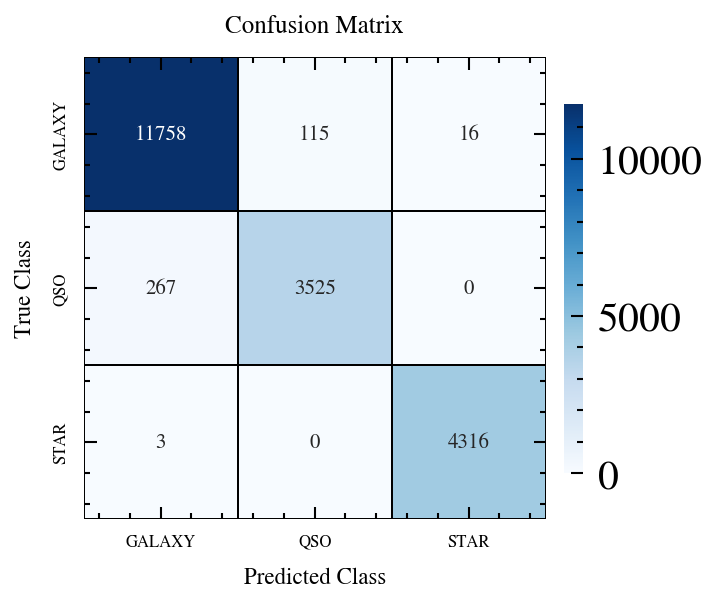

In [ ]:
import scienceplots
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

plt.style.use(['science', 'no-latex'])
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(4, 2), dpi=300)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True, cbar_kws={"shrink":0.8, "aspect":20, "pad":0.02},
    linewidths=0.1,
    linecolor="black",
    square=True,
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_,
    annot_kws={"size":5},
    ax=ax
)

# Labels
ax.set_xlabel("Predicted Class", fontsize=5.5)
ax.set_ylabel("True Class", fontsize=5.5)
ax.set_title("Confusion Matrix", fontsize=6)

# Tick formatting
ax.tick_params(axis='both', which='major', labelsize=4)

plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

      GALAXY       0.98      0.99      0.98     11889
         QSO       0.97      0.93      0.95      3792
        STAR       1.00      1.00      1.00      4319

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.98     20000
weighted avg       0.98      0.98      0.98     20000



In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
8,redshift,0.656847
6,z,0.097161
3,g,0.067226
2,u,0.059185
5,i,0.058122
4,r,0.036416
0,alpha,0.011100
1,delta,0.010970
7,cam_col,0.002972


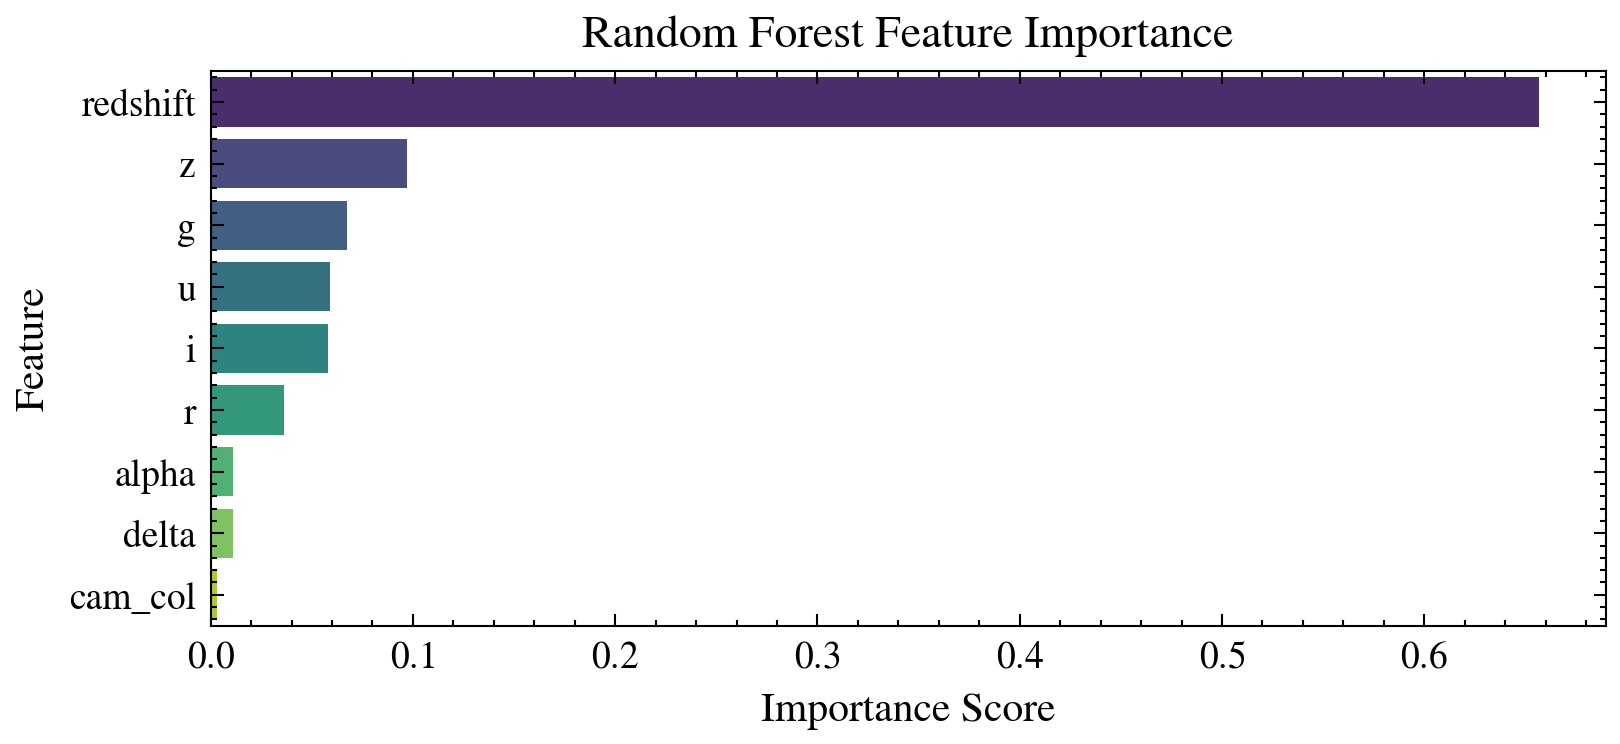

In [ ]:
fig, ax = plt.subplots(figsize=(6,2.4), dpi=300)
colors = sns.color_palette("viridis", len(feature_importance))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature",
    palette=colors,
    hue="Feature",
    dodge=False,
    legend=False,
    ax=ax
)

ax.set_xlabel("Importance Score", fontsize=10)
ax.set_ylabel("Feature", fontsize=10)
ax.set_title("Random Forest Feature Importance", fontsize=11)

ax.tick_params(direction='in', which='both', top=True, right=True, labelsize=9)
ax.minorticks_on()
plt.show()

In [ ]:
import shap
import pandas as pd

shap.initjs()
X_sample = pd.DataFrame(
    X_test_scaled[:200],
    columns=X.columns
)

explainer = shap.TreeExplainer(rf)
shap_values = explainer(X_sample)

print("SHAP values computed successfully!")

SHAP values computed successfully!


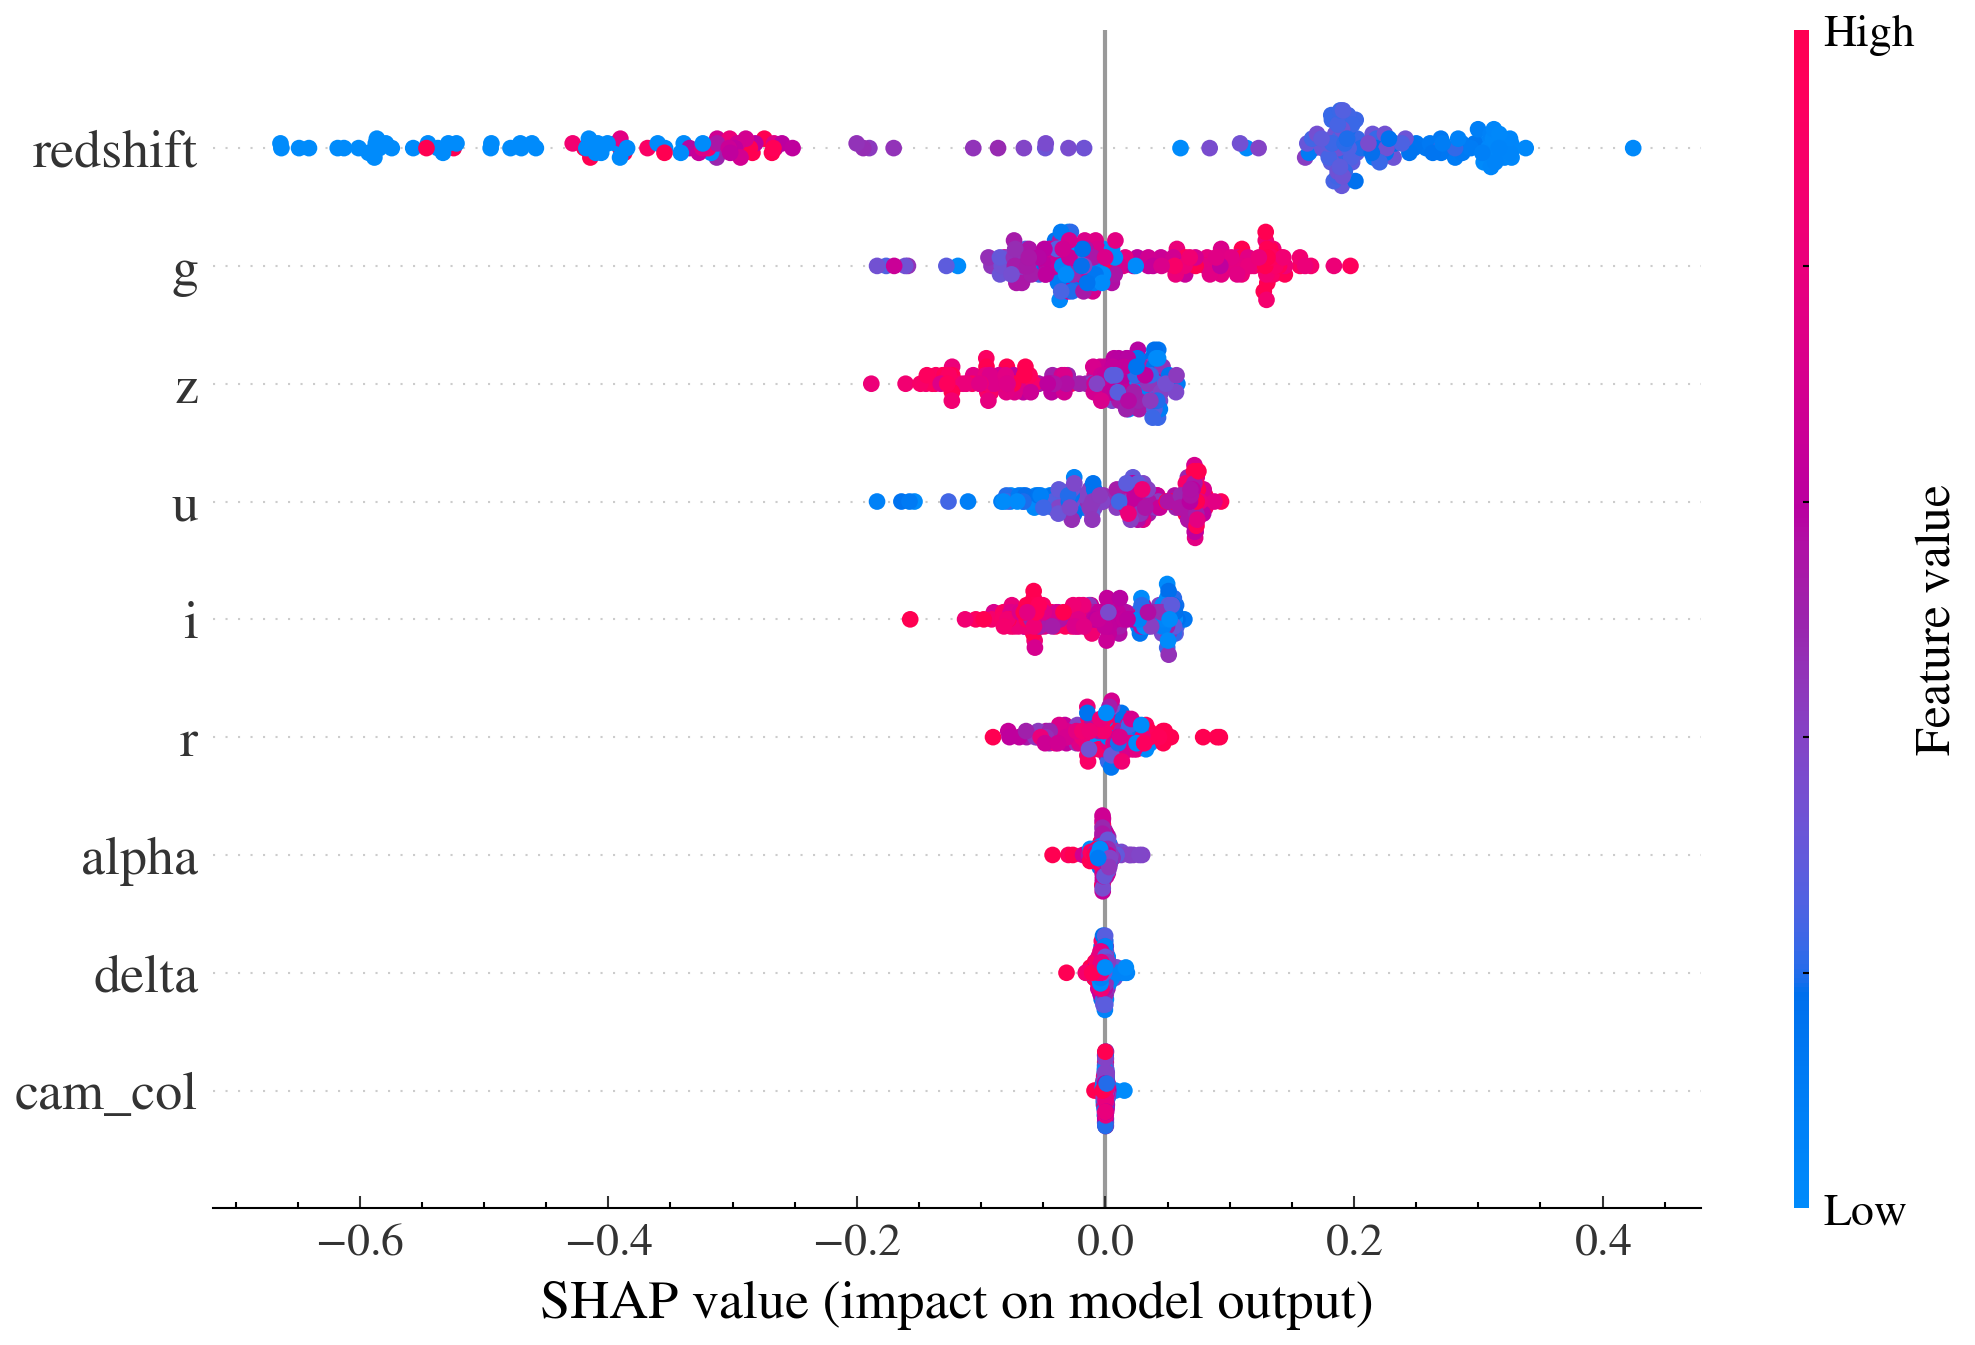

In [ ]:
import matplotlib as mpl

plt.style.use(['science', 'no-latex'])   # Use 'no-latex' unless LaTeX is installed
mpl.rcParams.update({
    "figure.figsize": (8,2.3),
    "figure.dpi": 300,
    "font.size": 9,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "legend.fontsize": 8,
})

# Create figure
plt.figure(figsize=(8, 2.3), dpi=300)

# SHAP beeswarm
shap.plots.beeswarm(
    shap_values[:, :, 0],
    max_display=9,
    show=False      # Important! Prevent SHAP from displaying immediately
)
plt.show()

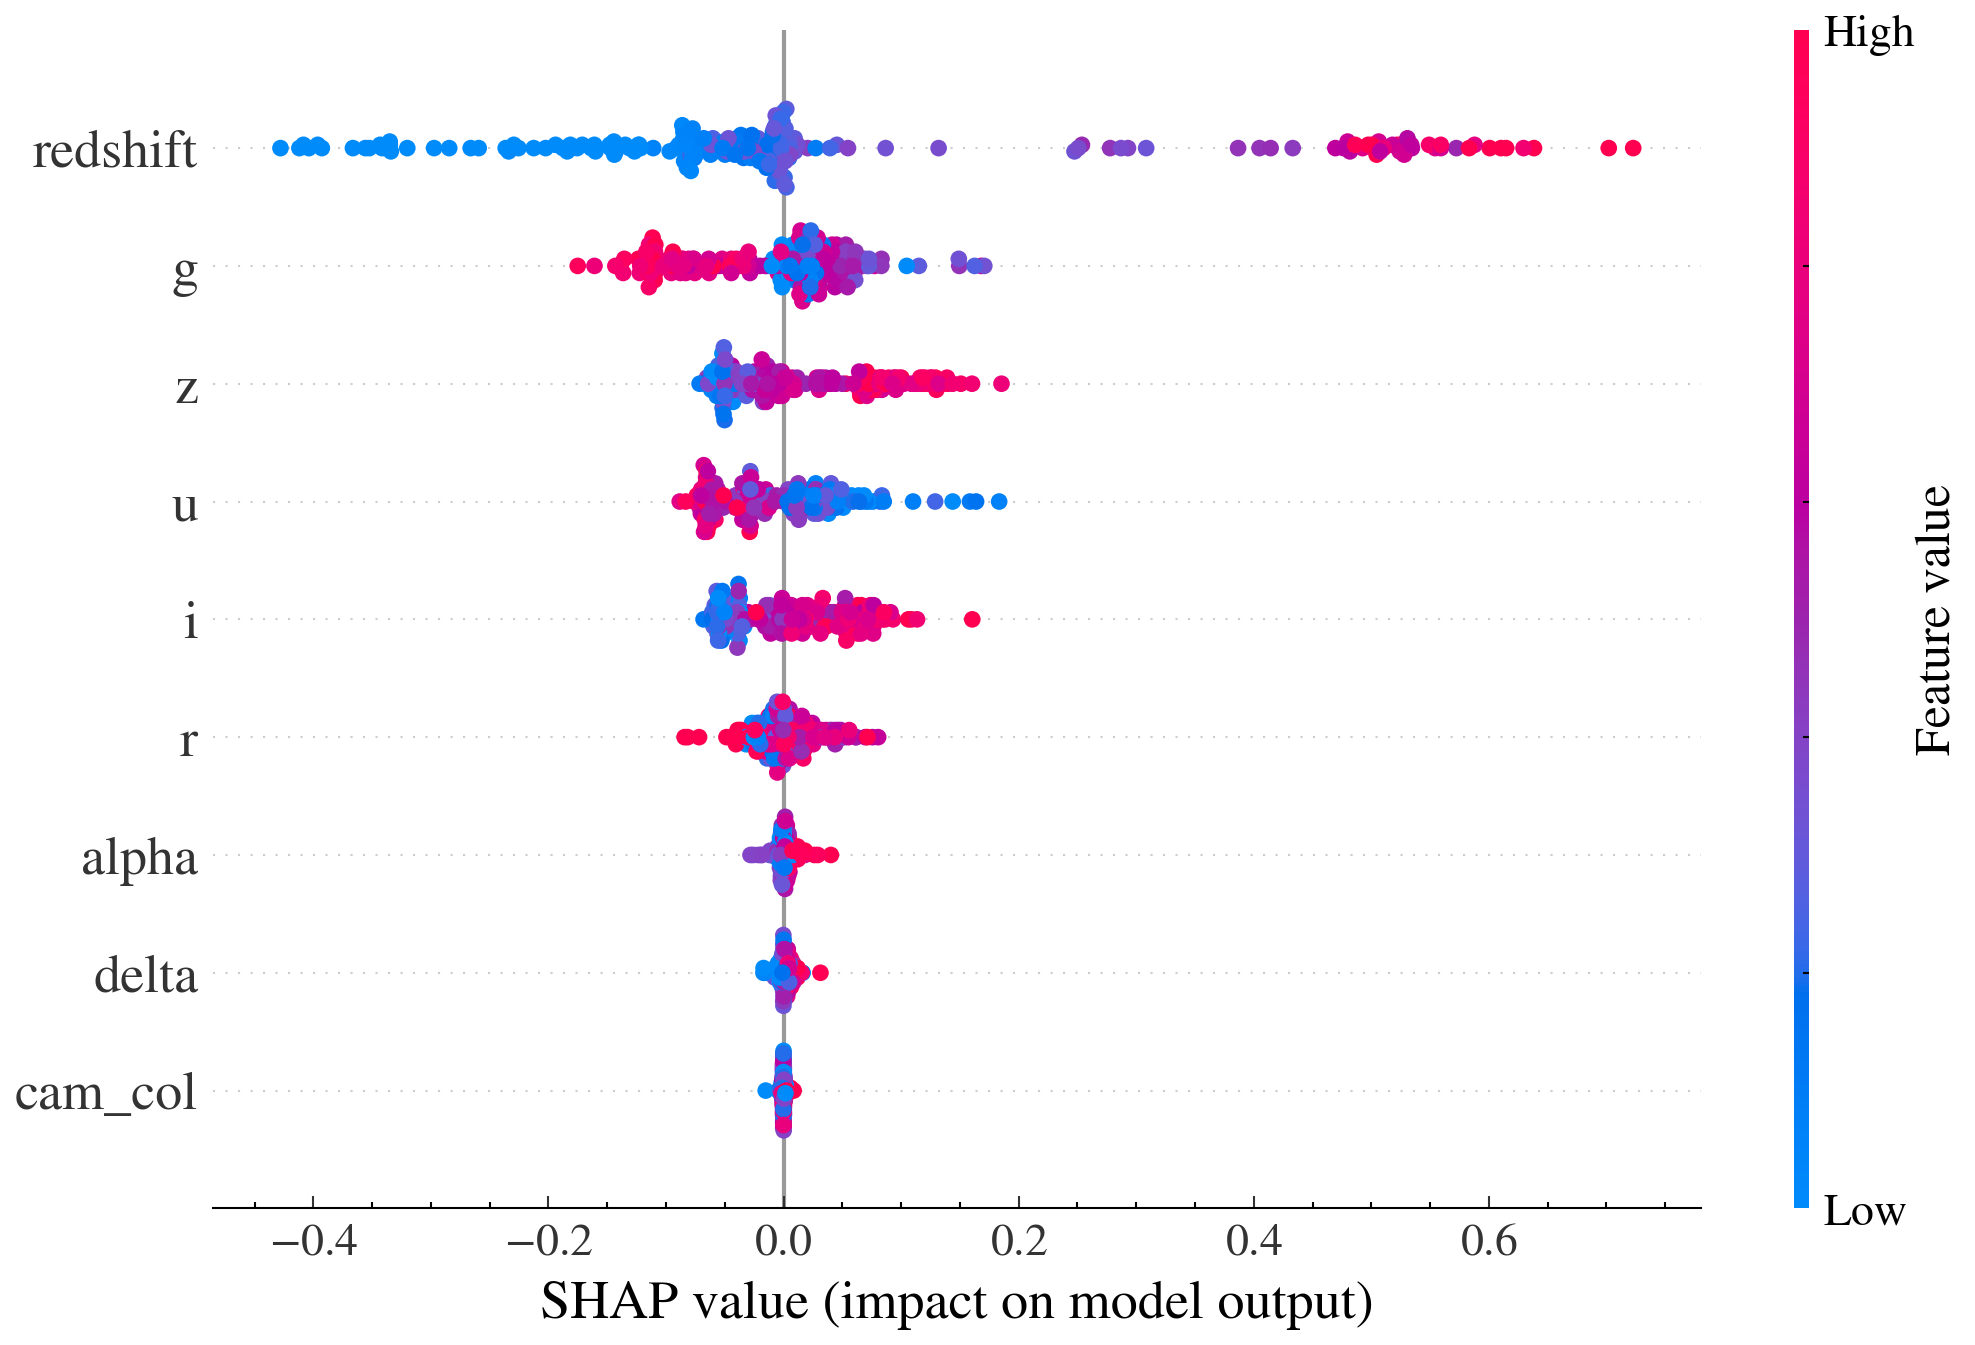

In [ ]:
import matplotlib as mpl

plt.style.use(['science', 'no-latex'])   # Use 'no-latex' unless LaTeX is installed
mpl.rcParams.update({
    "figure.figsize": (8,2),
    "figure.dpi": 300,
    "font.size": 9,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "legend.fontsize": 8,
})

# Create figure
plt.figure(figsize=(8, 2), dpi=300)

# SHAP beeswarm
shap.plots.beeswarm(
    shap_values[:, :, 1],
    max_display=9,
    show=False      # Important! Prevent SHAP from displaying immediately
)
plt.show()

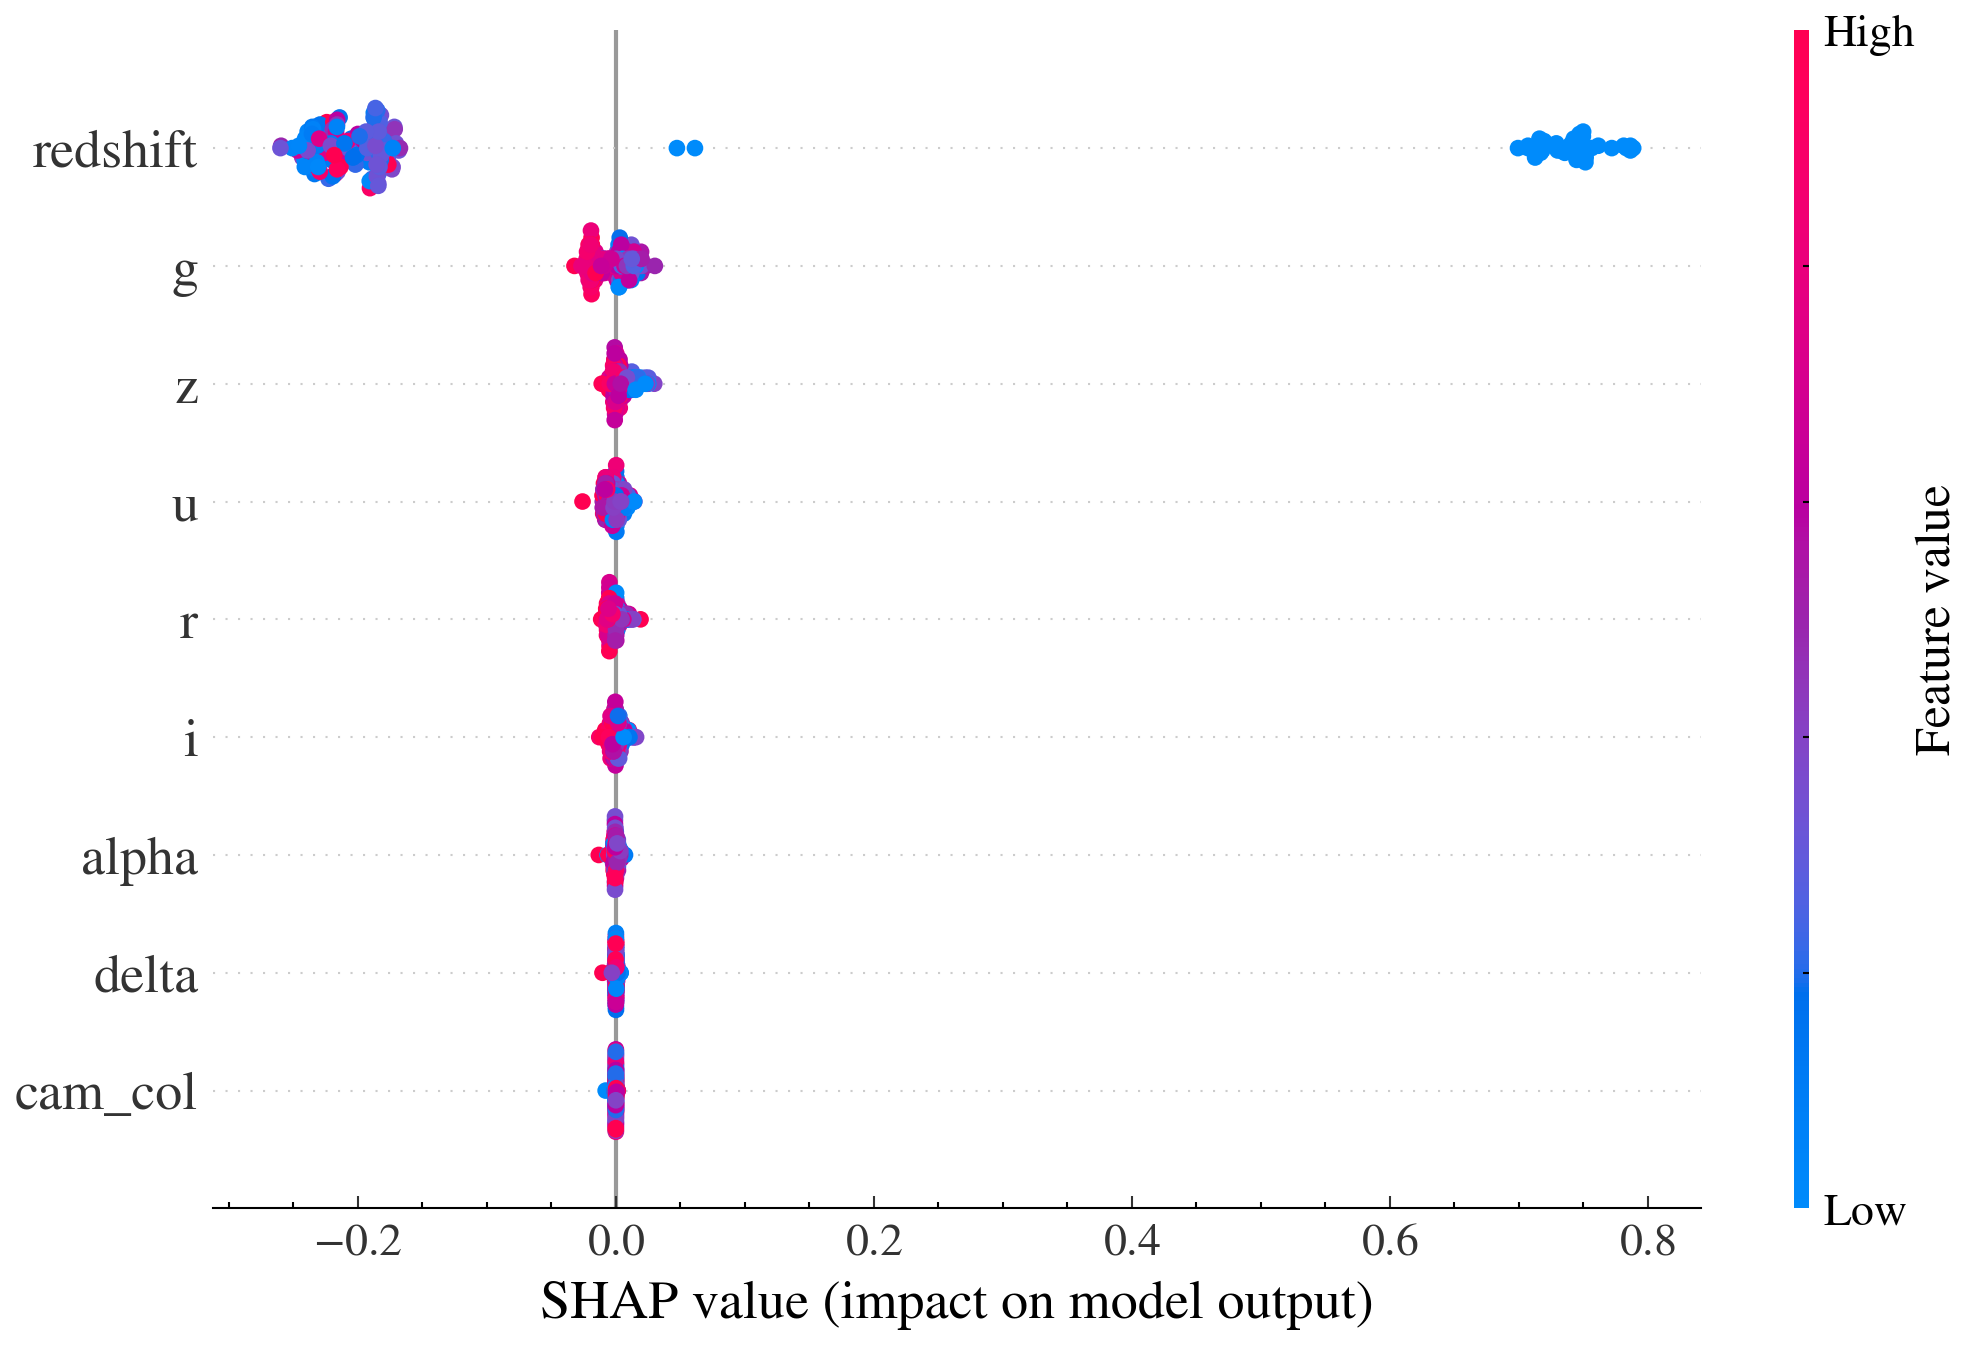

In [ ]:
import matplotlib as mpl

plt.style.use(['science', 'no-latex'])   # Use 'no-latex' unless LaTeX is installed
mpl.rcParams.update({
    "figure.figsize": (8,2),
    "figure.dpi": 300,
    "font.size": 9,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "legend.fontsize": 8,
})

# Create figure
plt.figure(figsize=(8, 2), dpi=300)

# SHAP beeswarm
shap.plots.beeswarm(
    shap_values[:, :, 2],
    max_display=9,
    show=False      # Important! Prevent SHAP from displaying immediately
)
plt.show()

# Conclusion

In this project, a Random Forest classifier was developed to classify SDSS astronomical objects into Galaxies, QSOs, and Stars. After preprocessing the data and training the model, an overall accuracy of approximately 98% was achieved.

Feature importance analysis showed that redshift is the most influential feature for classification. Explainable AI using SHAP further demonstrated how individual astronomical features contribute to each prediction, improving the transparency and interpretability of the model.

The results indicate that machine learning combined with explainable AI provides an effective and reliable approach for astronomical object classification.